In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)


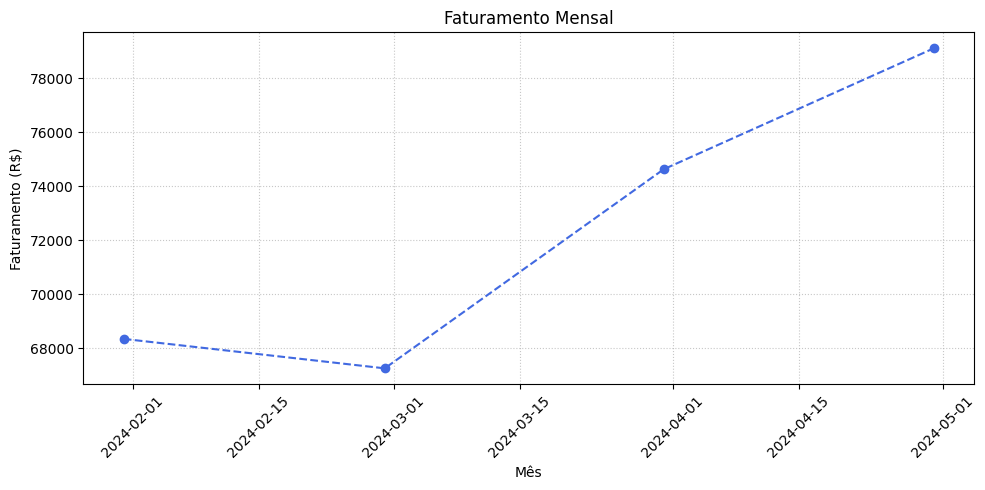

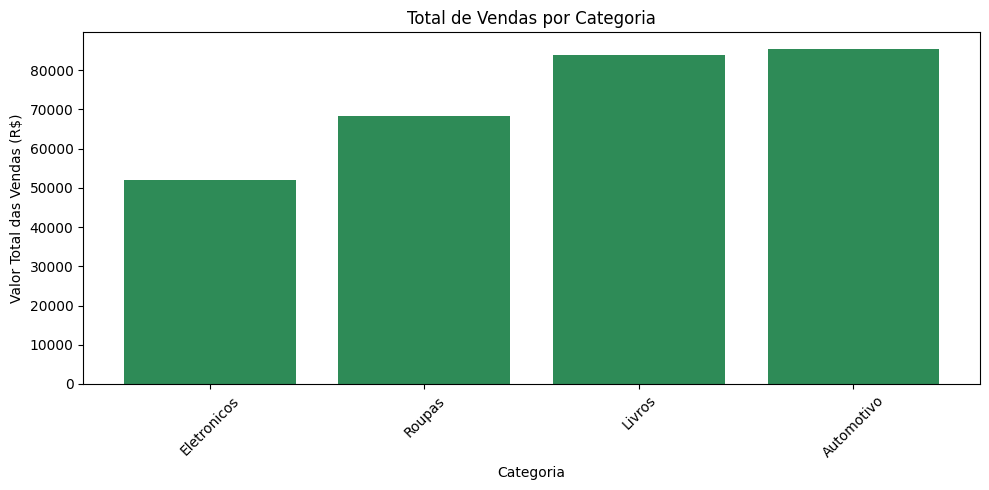

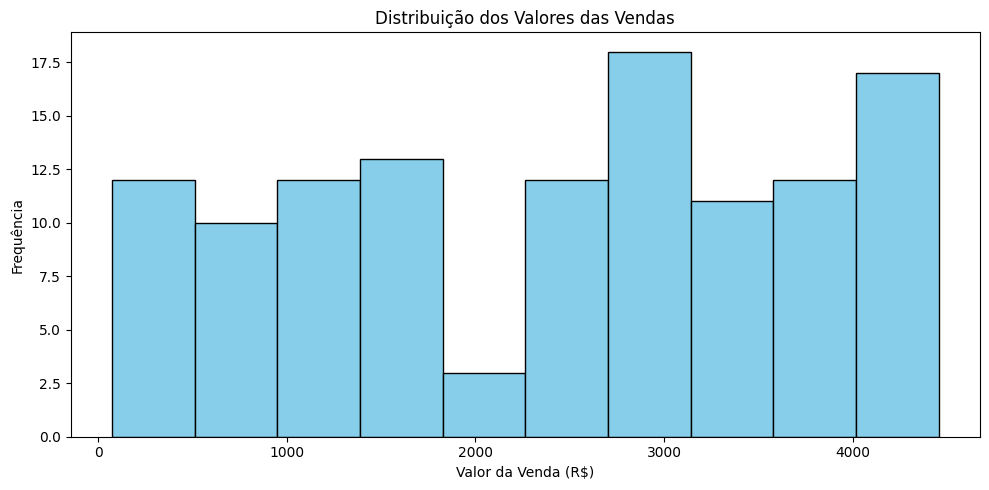

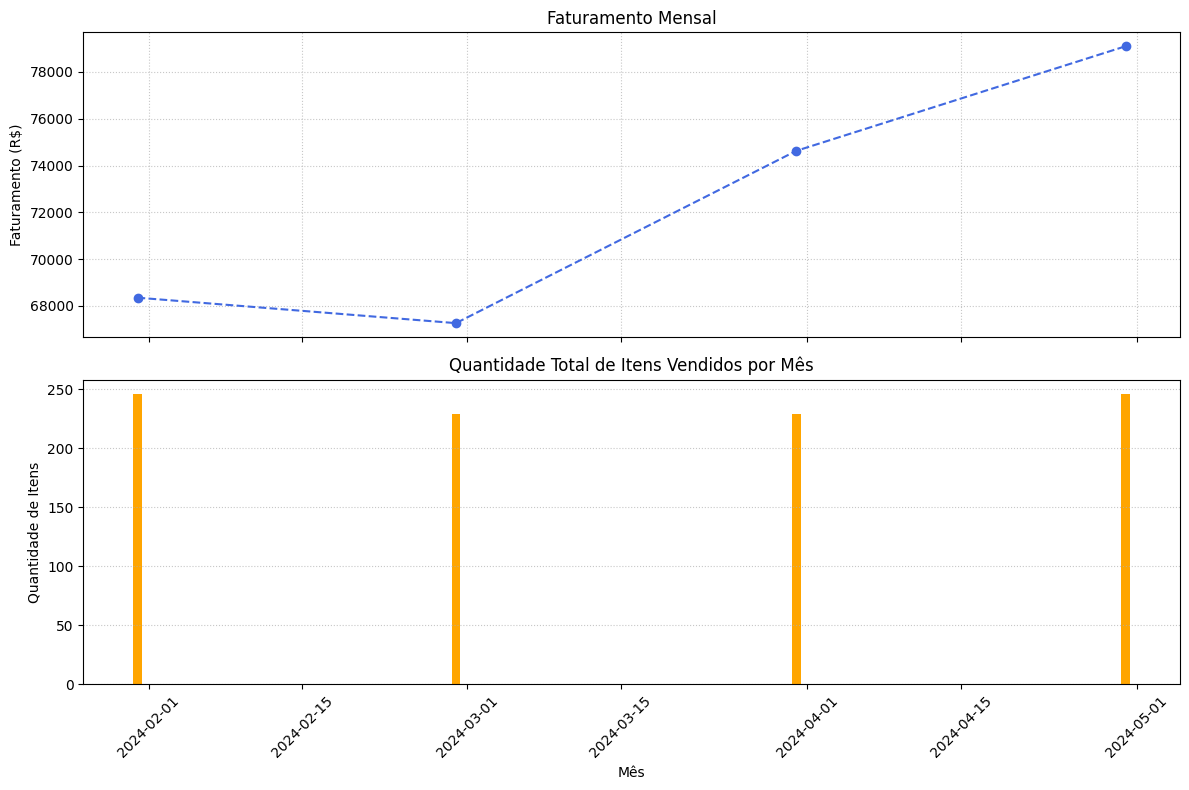

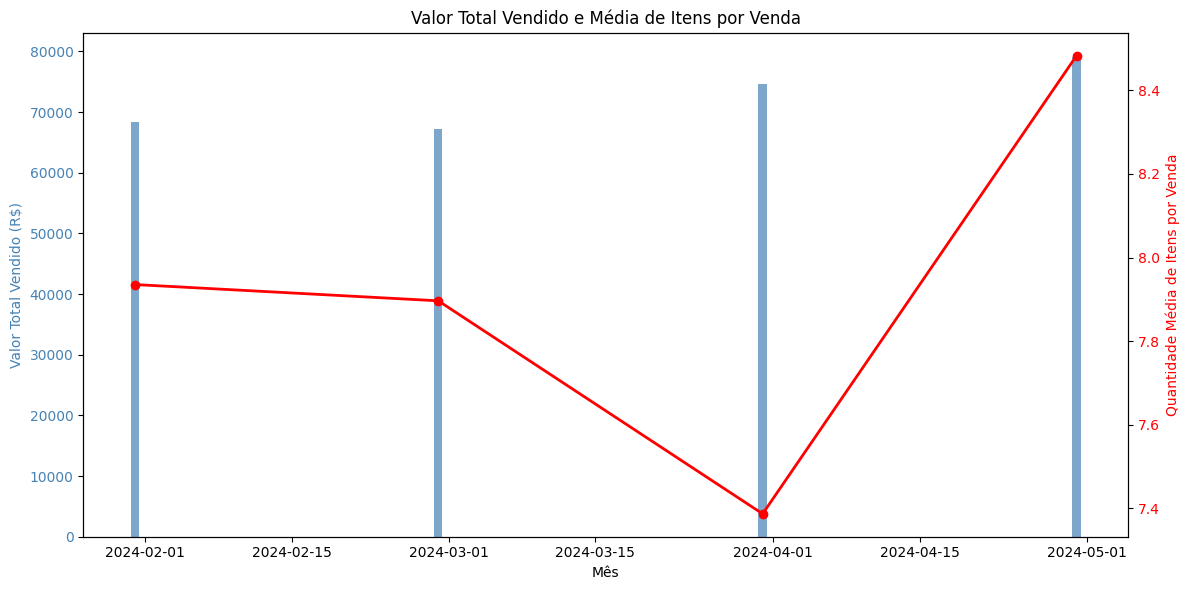

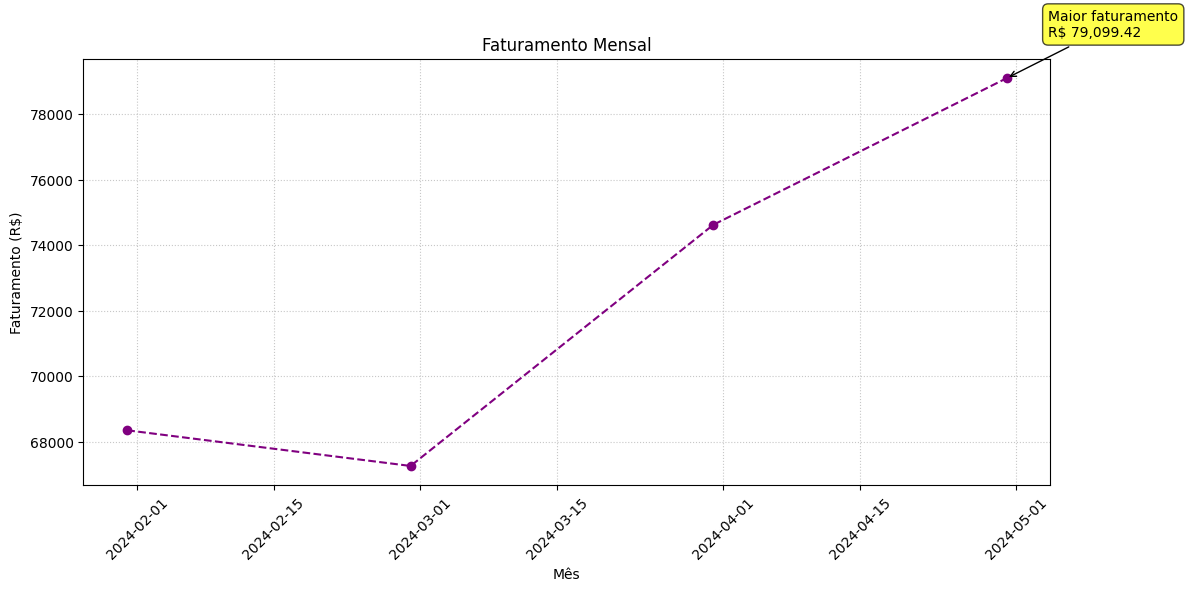

Tabela dinâmica:
estado             BA        MG        RJ        RS        SP
categoria                                                    
Automotivo    7514.28  15732.40  26383.20   9863.20  25878.61
Eletronicos  13455.10  13489.07   1197.84  14273.33   9468.10
Livros        4635.93  25664.89  10201.13  18900.98  24478.24
Roupas       27213.86   9417.84  11362.65   4578.10  15631.96


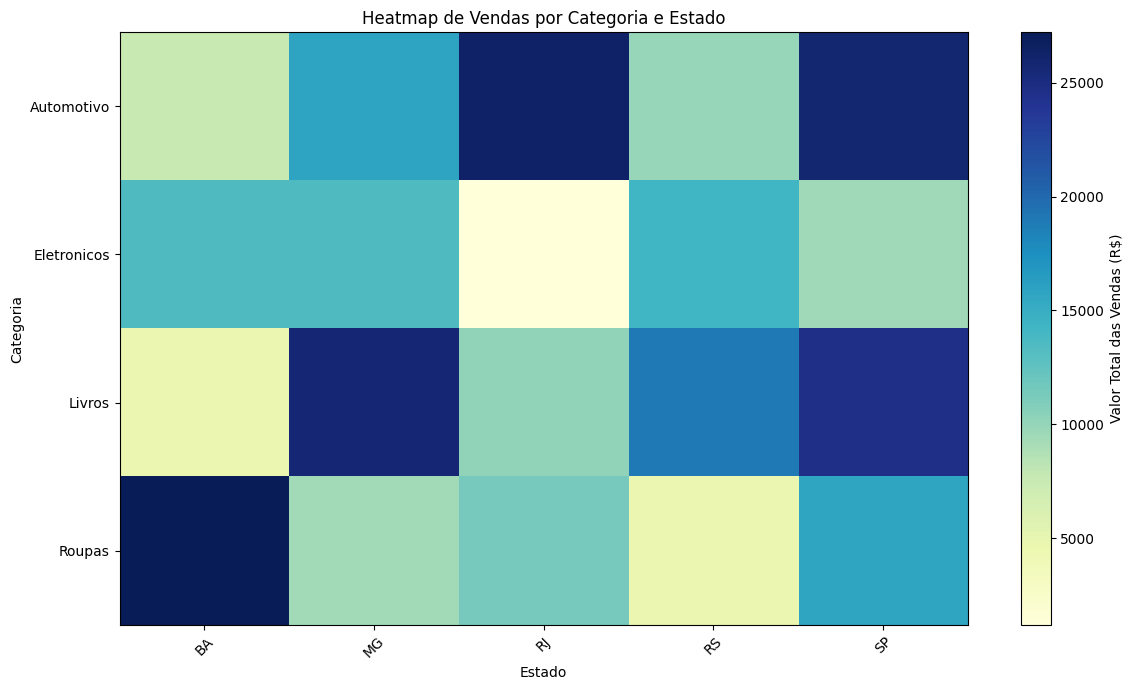

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PREPARAÇÃO DOS DADOS
# ============================================================

# Converter a coluna de data para datetime
df['data'] = pd.to_datetime(df['data'])

# Ordenar pela data
df = df.sort_values('data')

# Definir a data como índice
df = df.set_index('data')


# ============================================================
# PARTE 1 - GRÁFICOS ESSENCIAIS E PERSONALIZAÇÃO
# ============================================================

# ------------------------------------------------------------
# 1. Gráfico de linha - Faturamento mensal
# ------------------------------------------------------------

faturamento_mensal = df['valor'].resample('ME').sum()

plt.figure(figsize=(10, 5))

plt.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='royalblue'
)

plt.title('Faturamento Mensal')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.grid(True, linestyle=':', alpha=0.7)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Gráfico de barras - Total de vendas por categoria
# ------------------------------------------------------------

vendas_categoria = df.groupby('categoria')['valor'].sum().sort_values()

plt.figure(figsize=(10, 5))

plt.bar(
    vendas_categoria.index,
    vendas_categoria.values,
    color='seagreen'
)

plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Valor Total das Vendas (R$)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Histograma - Distribuição dos valores das vendas
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    df['valor'],
    bins=10,
    edgecolor='black',
    color='skyblue'
)

plt.title('Distribuição dos Valores das Vendas')
plt.xlabel('Valor da Venda (R$)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()


# ============================================================
# PARTE 2 - API ORIENTADA A OBJETOS E EIXOS MÚLTIPLOS
# ============================================================

# ------------------------------------------------------------
# 4. Figura com 2 subplots e eixo X compartilhado
# ------------------------------------------------------------

faturamento_mensal = df['valor'].resample('ME').sum()
quantidade_mensal = df['quantidade'].resample('ME').sum()

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)

# Ax1 - Faturamento mensal
ax1.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='royalblue'
)

ax1.set_title('Faturamento Mensal')
ax1.set_ylabel('Faturamento (R$)')
ax1.grid(True, linestyle=':', alpha=0.7)


# Ax2 - Quantidade de itens vendidos
ax2.bar(
    quantidade_mensal.index,
    quantidade_mensal.values,
    color='orange'
)

ax2.set_title('Quantidade Total de Itens Vendidos por Mês')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade de Itens')
ax2.grid(True, axis='y', linestyle=':', alpha=0.7)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Gráfico com dois eixos Y - twinx()
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

# Valor total vendido por mês
ax.bar(
    faturamento_mensal.index,
    faturamento_mensal.values,
    color='steelblue',
    alpha=0.7,
    label='Valor Total Vendido'
)

ax.set_xlabel('Mês')
ax.set_ylabel('Valor Total Vendido (R$)', color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')


# Quantidade média de itens por venda
media_itens = df['quantidade'].resample('ME').mean()

ax2 = ax.twinx()

ax2.plot(
    media_itens.index,
    media_itens.values,
    color='red',
    marker='o',
    linewidth=2,
    label='Média de Itens por Venda'
)

ax2.set_ylabel(
    'Quantidade Média de Itens por Venda',
    color='red'
)

ax2.tick_params(axis='y', labelcolor='red')

plt.title('Valor Total Vendido e Média de Itens por Venda')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Identificar o mês de maior faturamento e fazer anotação
# ------------------------------------------------------------

mes_maior_faturamento = faturamento_mensal.idxmax()
maior_faturamento = faturamento_mensal.max()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='purple'
)

ax.set_title('Faturamento Mensal')
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento (R$)')
ax.grid(True, linestyle=':', alpha=0.7)

# Anotação do pico
ax.annotate(
    f'Maior faturamento\nR$ {maior_faturamento:,.2f}',
    xy=(mes_maior_faturamento, maior_faturamento),
    xytext=(30, 30),
    textcoords='offset points',
    arrowprops=dict(
        arrowstyle='->',
        color='black'
    ),
    fontsize=10,
    bbox=dict(
        boxstyle='round,pad=0.4',
        fc='yellow',
        alpha=0.7
    )
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# PARTE 3 - MATRIZ DE INTENSIDADE / HEATMAP
# ============================================================

# ------------------------------------------------------------
# 7. Criar tabela dinâmica
# ------------------------------------------------------------

tabela_pivot = pd.pivot_table(
    df,
    values='valor',
    index='categoria',
    columns='estado',
    aggfunc='sum',
    fill_value=0
)

print('Tabela dinâmica:')
print(tabela_pivot)


# ------------------------------------------------------------
# 8. Criar Heatmap usando imshow()
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

heatmap = ax.imshow(
    tabela_pivot.values,
    cmap='YlGnBu',
    aspect='auto'
)

# Barra de cores
plt.colorbar(
    heatmap,
    ax=ax,
    label='Valor Total das Vendas (R$)'
)

# Rótulos do eixo X
ax.set_xticks(range(len(tabela_pivot.columns)))
ax.set_xticklabels(tabela_pivot.columns)

# Rótulos do eixo Y
ax.set_yticks(range(len(tabela_pivot.index)))
ax.set_yticklabels(tabela_pivot.index)

ax.set_xlabel('Estado')
ax.set_ylabel('Categoria')
ax.set_title('Heatmap de Vendas por Categoria e Estado')

plt.xticks(rotation=45)
plt.tight_layout()


# ------------------------------------------------------------
# 9. Salvar a figura em PNG com 300 DPI
# ------------------------------------------------------------

plt.savefig(
    'heatmap_vendas.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
